In [1]:
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2

from src.runners import run_vqe_trace
from src.transformations import (
    vqe_identity,
    vqe_barrier,
    vqe_identity_xx,
    vqe_global_phase,
    vqe_fault_x,
    vqe_fault_replace_rotation,
    vqe_fault_shift_parameter,
    vqe_fault_change_entanglement,
    vqe_fault_shift_parameter_strong,
    vqe_fault_replace_rotation_strong,

)
from src.checker import evaluate_vqe_pair

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12})

project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("VQE Metamorphic Testing Notebook")
print("=" * 50)
print(f"Project root: {project_root}")
print(f"Results dir: {results_dir}")
print(f"Figures dir: {figures_dir}")

VQE Metamorphic Testing Notebook
Project root: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing
Results dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results
Figures dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\figures


In [3]:
# VQE METAMORPHIC TESTING WITH COMMUTING SYMMETRY

NUM_QUBITS = 4
NUM_RUNS = 30

ENERGY_THRESHOLD = 1e-3
SYMMETRY_THRESHOLD = 1e-3
PARAM_THRESHOLD = 1e-2
REPS = 5
MAXITER = 120
RANDOM_SEED = 42

# This Hamiltonian commutes with ZZII + IIZZ.
# It consists of two 2-qubit transverse-style blocks:
#   qubits 0,1: -ZZ + 0.5 XX
#   qubits 2,3: -ZZ + 0.5 XX

H = SparsePauliOp(
    ["ZZII", "IIZZ", "XXII", "IIXX"],
    coeffs=[-1.0, -1.0, 0.5, 0.5]
)

# True symmetry observable
symmetry_op = SparsePauliOp(
    ["ZZII", "IIZZ"],
    coeffs=[1.0, 1.0]
)

# COMMUTATOR CHECK

def check_commutation(A, B, label_A="A", label_B="B"):
    """
    Check whether two SparsePauliOp operators commute.
    """

    comm = (A @ B - B @ A).simplify(atol=1e-12)

    print(f"\nCommutator [{label_A}, {label_B}]:")
    print(comm)

    if len(comm.paulis) == 0 or np.allclose(comm.coeffs, 0.0):
        print("Result: operators commute.\n")
        return True
    else:
        print("Result: operators do NOT commute.\n")
        return False


commutes = check_commutation(H, symmetry_op, "H", "symmetry_op")

# ANSATZ

ansatz = efficient_su2(
    NUM_QUBITS,
    reps=REPS,
    entanglement="full"
)

print("Original ansatz:")
print(f"Number of qubits: {ansatz.num_qubits}")
print(f"Number of parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.depth()}")


# METAMORPHIC RELATIONS

relations = {
    "identity": {
        "transform": vqe_identity,
        "type": "valid",
    },
    "barrier": {
        "transform": vqe_barrier,
        "type": "valid",
    },
    "identity_xx": {
        "transform": vqe_identity_xx,
        "type": "valid",
    },
   
    "fault_x": {
        "transform": vqe_fault_x,
        "type": "fault",
    },
    "fault_replace_rot": {
        "transform": vqe_fault_replace_rotation,
        "type": "fault",
    },
    "fault_shift_param": {
        "transform": vqe_fault_shift_parameter,
        "type": "fault",
    },
    "fault_change_entanglement": {
        "transform": vqe_fault_change_entanglement,
        "type": "fault",
    },
    "fault_replace_rot_strong": {
        "transform": vqe_fault_replace_rotation_strong,
        "type": "fault",
    },   
    "fault_shift_param_strong": {
        "transform": vqe_fault_shift_parameter_strong,
        "type": "fault",
    },
}
        


# HELPER FUNCTION

def apply_transform(transform, ansatz, seed):
    """
    Apply a VQE transformation.

    Some transformations accept seed, while valid ones such as
    vqe_identity and vqe_barrier do not.
    """

    try:
        return transform(ansatz, seed=seed)
    except TypeError:
        return transform(ansatz)


# PRE-GENERATE INITIAL POINTS

rng = np.random.default_rng(RANDOM_SEED)

initial_points = [
    rng.uniform(-0.1, 0.1, ansatz.num_parameters)
    for _ in range(NUM_RUNS)
]


# MAIN VQE METAMORPHIC TESTING EXPERIMENT

results = []
run_level_results = []

print(f"\nRunning VQE metamorphic testing ({NUM_RUNS} paired runs per relation)...\n")

for relation_name, relation_info in relations.items():

    transform = relation_info["transform"]
    relation_type = relation_info["type"]

    print(f"→ Testing: {relation_name}")

    delta_E_list = []
    avg_energy_diff_list = []
    max_energy_diff_list = []

    sym_diff_list = []
    max_sym_diff_list = []

    param_diff_list = []
    max_param_diff_list = []

    detected_list = []

    for run in range(NUM_RUNS):

        initial_point = initial_points[run]

        # Source VQE run

        source_result, source_trace = run_vqe_trace(
            ansatz=ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point,
            maxiter=MAXITER,
        )

    
        # Follow-up transformed ansatz

        follow_ansatz = apply_transform(
            transform=transform,
            ansatz=ansatz,
            seed=1000 + run,
        )

        # Reuse same initial point when parameter count matches.
        # This should be true for the current VQE transformations.
        if follow_ansatz.num_parameters == ansatz.num_parameters:
            follow_initial_point = initial_point
        else:
            follow_initial_point = rng.uniform(
                -0.1,
                0.1,
                follow_ansatz.num_parameters,
            )

        # Follow-up VQE run

        follow_result, follow_trace = run_vqe_trace(
            ansatz=follow_ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=follow_initial_point,
            maxiter=MAXITER,
        )

        # Evaluate source/follow-up pair

        metrics = evaluate_vqe_pair(
            source_result,
            follow_result,
            source_trace,
            follow_trace,
            energy_threshold=ENERGY_THRESHOLD,
            symmetry_threshold=SYMMETRY_THRESHOLD,
            param_threshold=PARAM_THRESHOLD,
        )

        delta_E_list.append(metrics["delta_E"])
        avg_energy_diff_list.append(metrics["avg_energy_diff"])
        max_energy_diff_list.append(metrics["max_energy_diff"])

        sym_diff_list.append(metrics["avg_sym_diff"])
        max_sym_diff_list.append(metrics["max_sym_diff"])

        param_diff_list.append(metrics["avg_param_diff"])
        max_param_diff_list.append(metrics["max_param_diff"])

        detected_list.append(metrics["violation"])

        run_level_results.append({
            "relation": relation_name,
            "type": relation_type,
            "run": run + 1,

            "source_num_parameters": ansatz.num_parameters,
            "follow_num_parameters": follow_ansatz.num_parameters,

            "source_depth": ansatz.depth(),
            "follow_depth": follow_ansatz.depth(),

            "delta_E": round(metrics["delta_E"], 8),
            "avg_energy_diff": round(metrics["avg_energy_diff"], 8),
            "max_energy_diff": round(metrics["max_energy_diff"], 8),

            "avg_sym_diff": round(metrics["avg_sym_diff"], 8),
            "max_sym_diff": round(metrics["max_sym_diff"], 8),

            "avg_param_diff": round(metrics["avg_param_diff"], 8),
            "max_param_diff": round(metrics["max_param_diff"], 8),

            "trace_len": metrics["trace_len"],
            "violation": metrics["violation"],
        })

    results.append({
        "relation": relation_name,
        "type": relation_type,

        "mean_delta_E": round(np.mean(delta_E_list), 6),
        "std_delta_E": round(np.std(delta_E_list), 6),

        "mean_avg_energy_diff": round(np.mean(avg_energy_diff_list), 6),
        "mean_max_energy_diff": round(np.mean(max_energy_diff_list), 6),

        "mean_sym_diff": round(np.mean(sym_diff_list), 6),
        "mean_max_sym_diff": round(np.mean(max_sym_diff_list), 6),

        "mean_param_diff": round(np.mean(param_diff_list), 6),
        "mean_max_param_diff": round(np.mean(max_param_diff_list), 6),

        "detection_rate": round(np.mean(detected_list) * 100, 2),
    })


# SAVE RESULTS

df_vqe = pd.DataFrame(results)
df_vqe_runs = pd.DataFrame(run_level_results)

df_vqe.to_csv(results_dir / "vqe_results_4q.csv", index=False)
df_vqe_runs.to_csv(results_dir / "vqe_run_level_results_4q.csv", index=False)

print("\nExperiment completed.")
print(f"Summary results saved to: {results_dir / 'vqe_results_4q.csv'}")
print(f"Run-level results saved to: {results_dir / 'vqe_run_level_results_4q.csv'}")

display(df_vqe)
display(df_vqe_runs.head())


Commutator [H, symmetry_op]:
SparsePauliOp(['IIII'],
              coeffs=[0.+0.j])
Result: operators commute.

Original ansatz:
Number of qubits: 4
Number of parameters: 48
Circuit depth: 33

Running VQE metamorphic testing (30 paired runs per relation)...

→ Testing: identity
→ Testing: barrier
→ Testing: identity_xx
→ Testing: fault_x
→ Testing: fault_replace_rot
→ Testing: fault_shift_param
→ Testing: fault_change_entanglement
→ Testing: fault_replace_rot_strong
→ Testing: fault_shift_param_strong

Experiment completed.
Summary results saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_results_4q.csv
Run-level results saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_run_level_results_4q.csv


,relation,type,mean_delta_E,std_delta_E,mean_avg_energy_diff,mean_max_energy_diff,mean_sym_diff,mean_max_sym_diff,mean_param_diff,mean_max_param_diff,detection_rate
0,identity,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,barrier,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,identity_xx,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,fault_x,fault,0.228410,0.216641,0.554910,2.009532,0.395848,1.711397,3.067780,4.175201,100.0
4,fault_replace_rot,fault,0.068360,0.069643,0.105566,0.919561,0.078148,0.845041,1.085081,2.164741,100.0
5,fault_shift_param,fault,0.163269,0.152212,0.245844,1.091033,0.184149,0.970410,1.795452,2.960530,100.0
6,fault_change_entanglement,fault,0.281982,0.190702,0.260649,1.200008,0.161180,1.016901,2.829727,4.072373,100.0
7,fault_replace_rot_strong,fault,0.302711,0.236967,0.572032,1.654105,0.526516,1.548795,3.648947,4.977317,100.0
8,fault_shift_param_strong,fault,0.331737,0.262484,0.636484,1.820952,0.593471,1.787473,3.421922,4.790317,100.0


,relation,type,run,source_num_parameters,follow_num_parameters,source_depth,follow_depth,delta_E,avg_energy_diff,max_energy_diff,avg_sym_diff,max_sym_diff,avg_param_diff,max_param_diff,trace_len,violation
0,identity,valid,1,48,48,33,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,False
1,identity,valid,2,48,48,33,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,False
2,identity,valid,3,48,48,33,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,False
3,identity,valid,4,48,48,33,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,False
4,identity,valid,5,48,48,33,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,False


In [4]:
# SUMMARY TABLE BY RELATION TYPE

summary_vqe = df_vqe.groupby("type").agg({
    "mean_delta_E": "mean",
    "mean_sym_diff": "mean",
    "mean_param_diff": "mean",
    "detection_rate": "mean"
}).round(6)

print("=================== VQE SUMMARY =============")
display(summary_vqe)

summary_vqe.to_csv(results_dir / "vqe_summary_4q.csv")

=================== VQE SUMMARY =============


,mean_delta_E,mean_sym_diff,mean_param_diff,detection_rate
type,,,,
fault,0.229412,0.323219,2.641485,100.0
valid,0.000000,0.000000,0.000000,0.0


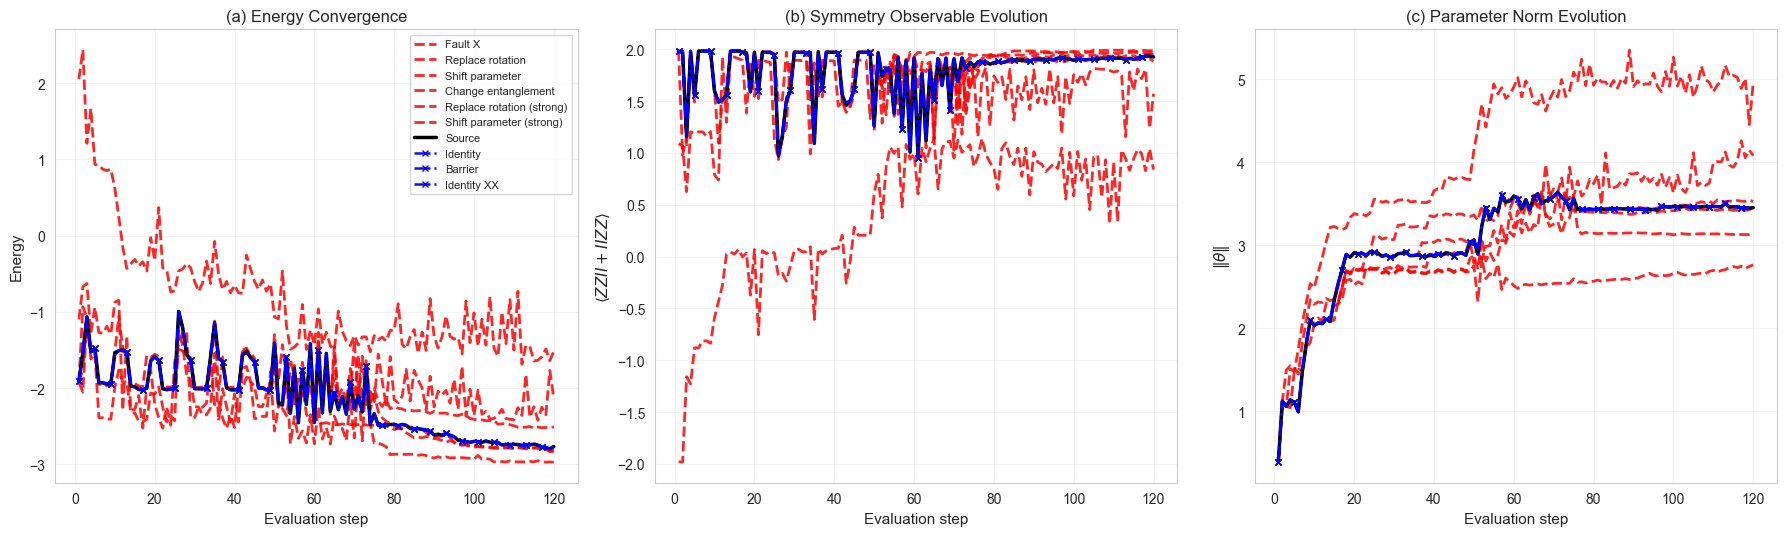

In [9]:
# STATEVECTOR VQE OPTIMIZATION PATHS

def pretty_relation_name(name: str) -> str:
    mapping = {
        "identity": "Identity",
        "barrier": "Barrier",
        "identity_xx": "Identity XX",
        "fault_x": "Fault X",
        "fault_replace_rot": "Replace rotation",
        "fault_replace_rot_strong": "Replace rotation (strong)",
        "fault_shift_param": "Shift parameter",
        "fault_shift_param_strong": "Shift parameter (strong)",
        "fault_change_entanglement": "Change entanglement",
    }
    return mapping.get(name, name)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "lines.linewidth": 2.0,
})

# Use one representative initial point for the figure
initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
    maxiter=MAXITER,
)

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):
    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1_000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
        maxiter=MAXITER,
    )

    followup_traces.append((name, follow_trace))

valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=False)

# ============================================================
# (a) ENERGY PLOT
# ============================================================

for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation step")
axes[0].set_ylabel("Energy")
axes[0].set_title("(a) Energy Convergence")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="best", frameon=True)

# ============================================================
# (b) SYMMETRY PLOT
# ============================================================

for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation step")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("(b) Symmetry Observable Evolution")
axes[1].grid(True, alpha=0.25)

# ============================================================
# (c) PARAMETER NORM PLOT
# ============================================================

for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation step")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("(c) Parameter Norm Evolution")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_optimization_paths.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

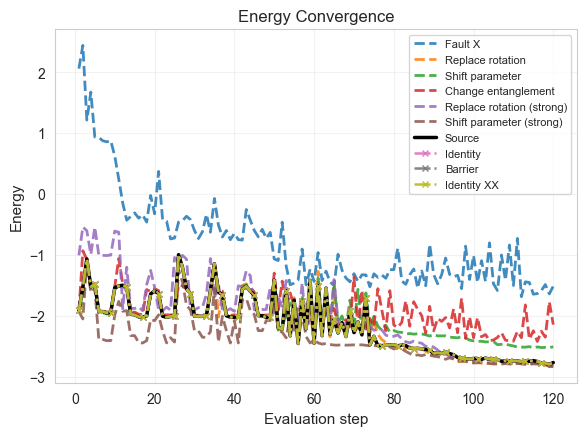

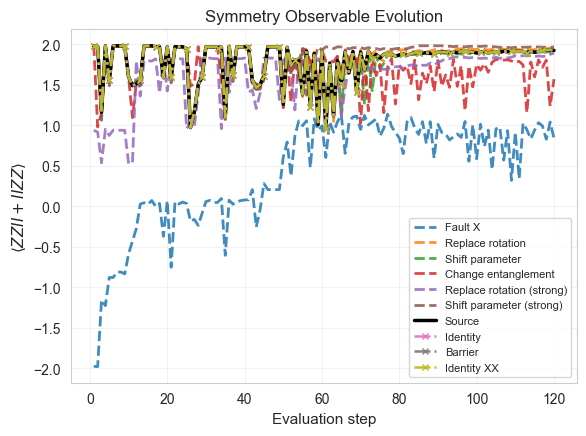

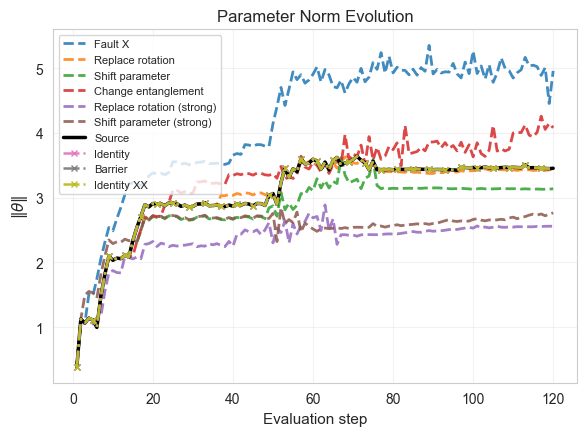

In [7]:
# ============================================================
# STATEVECTOR SEPARATE PLOTS
# ============================================================

# ---------------------------
# (a) Energy
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel("Energy")
ax.set_title("Energy Convergence")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_statevector_energy.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_statevector_energy.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------
# (b) Symmetry
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
ax.set_title("Symmetry Observable Evolution")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_statevector_symmetry.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_statevector_symmetry.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------
# (c) Parameter norm
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel(r"$\|\theta\|$")
ax.set_title("Parameter Norm Evolution")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_statevector_param.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_statevector_param.png", dpi=300, bbox_inches="tight")
plt.show()

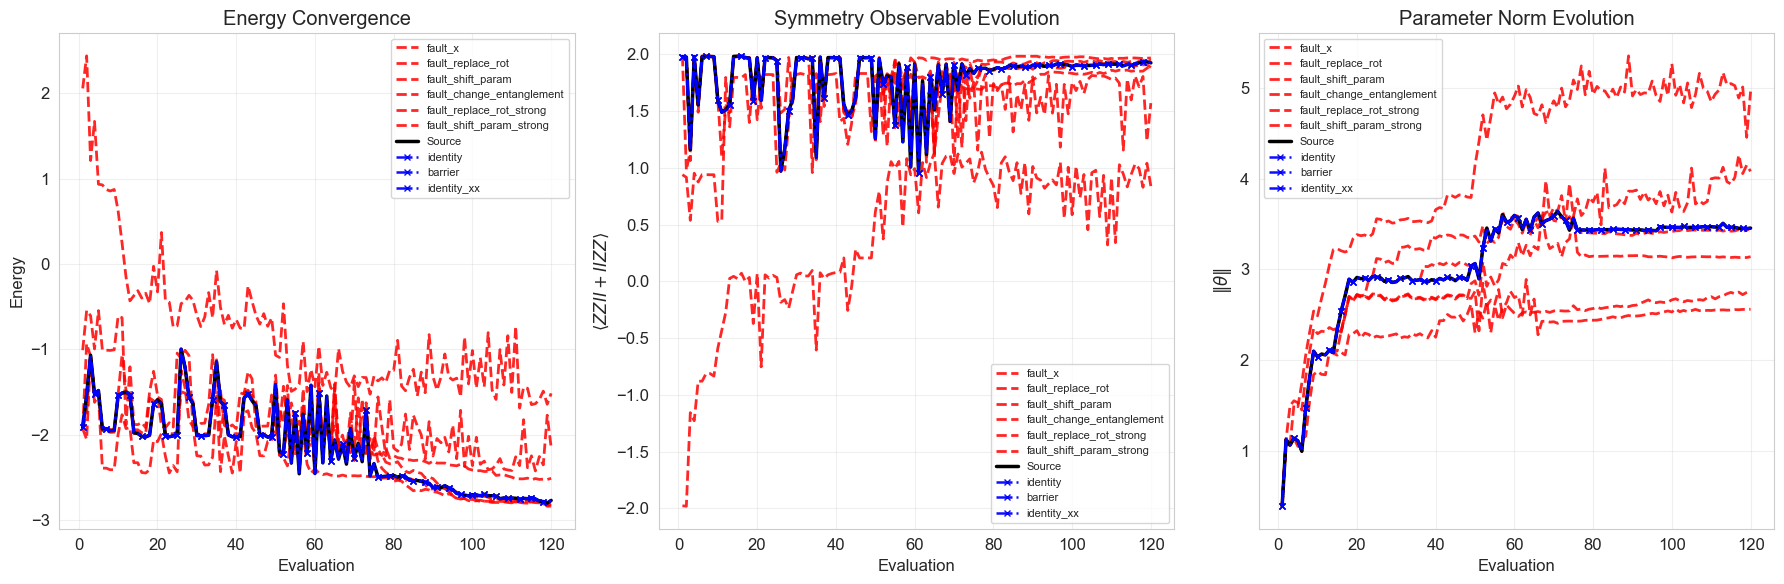

In [5]:
# FINAL VQE OPTIMIZATION PATHS

# One representative initial point for the figure.
initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):

    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
    )

    followup_traces.append((name, follow_trace))


valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]


# ENERGY PLOT

for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation")
axes[0].set_ylabel("Energy")
axes[0].set_title("Energy Convergence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)


# SYMMETRY OBSERVABLE PLOT

for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("Symmetry Observable Evolution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)


# PARAMETER NORM PLOT

for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("Parameter Norm Evolution")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)


# SAVE FIGURE

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_optimization_paths.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [6]:
# THRESHOLD SENSITIVITY TEST for the 4 qubit statevector

df = pd.read_csv(results_dir / "vqe_run_level_results_4q.csv")

if "phase" in df.columns:
    df = df[df["phase"] == "statevector"].copy()

# Candidate threshold grids
ENERGY_VALUES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
SYMMETRY_VALUES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
PARAM_VALUES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 5e-1, 1.0]

tuning_results = []

for e_th in ENERGY_VALUES:
    for s_th in SYMMETRY_VALUES:
        for p_th in PARAM_VALUES:

            predicted_violation = (
                (df["delta_E"] > e_th) |
                (df["max_sym_diff"] > s_th) |
                (df["max_param_diff"] > p_th)
            )

            valid_mask = df["type"] == "valid"
            fault_mask = df["type"] == "fault"

            fp_rate = predicted_violation[valid_mask].mean() * 100
            tp_rate = predicted_violation[fault_mask].mean() * 100

            tp = int(predicted_violation[fault_mask].sum())
            fn = int((~predicted_violation[fault_mask]).sum())
            fp = int(predicted_violation[valid_mask].sum())
            tn = int((~predicted_violation[valid_mask]).sum())

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0 else 0.0
            )

            tuning_results.append({
                "energy_threshold": e_th,
                "symmetry_threshold": s_th,
                "param_threshold": p_th,
                "fp_rate_pct": round(fp_rate, 2),
                "tp_rate_pct": round(tp_rate, 2),
                "precision": round(precision, 4),
                "recall": round(recall, 4),
                "f1_score": round(f1, 4),
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
            })

df_tuning = pd.DataFrame(tuning_results)

# Best settings: prefer zero false positives, then highest F1 / recall
df_best = df_tuning[df_tuning["fp_rate_pct"] == 0].sort_values(
    by=["f1_score", "tp_rate_pct"],
    ascending=[False, False]
)

display(df_best.head(20))
df_tuning.to_csv(results_dir / "vqe_threshold_sensitivity_4q.csv", index=False)

,energy_threshold,symmetry_threshold,param_threshold,fp_rate_pct,tp_rate_pct,precision,recall,f1_score,tp,fp,tn,fn
0,0.000001,0.000001,0.000001,0.0,100.0,1.0,1.0,1.0,180,0,90,0
1,0.000001,0.000001,0.000010,0.0,100.0,1.0,1.0,1.0,180,0,90,0
2,0.000001,0.000001,0.000100,0.0,100.0,1.0,1.0,1.0,180,0,90,0
3,0.000001,0.000001,0.001000,0.0,100.0,1.0,1.0,1.0,180,0,90,0
4,0.000001,0.000001,0.010000,0.0,100.0,1.0,1.0,1.0,180,0,90,0
5,0.000001,0.000001,0.100000,0.0,100.0,1.0,1.0,1.0,180,0,90,0
6,0.000001,0.000001,0.500000,0.0,100.0,1.0,1.0,1.0,180,0,90,0
7,0.000001,0.000001,1.000000,0.0,100.0,1.0,1.0,1.0,180,0,90,0
8,0.000001,0.000010,0.000001,0.0,100.0,1.0,1.0,1.0,180,0,90,0
9,0.000001,0.000010,0.000010,0.0,100.0,1.0,1.0,1.0,180,0,90,0


In [6]:
print("Parameters:", ansatz.num_parameters)
print(ansatz.draw("text"))

Parameters: 48
     ┌──────────┐┌──────────┐               ┌──────────┐┌───────────┐»
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[4]) ├──■────■────■──┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├»
     ├──────────┤├──────────┤┌─┴─┐  │    │  └──────────┘└───────────┘»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├┤ X ├──┼────┼───────■────────────■──────»
     ├──────────┤├──────────┤└───┘┌─┴─┐  │     ┌─┴─┐          │      »
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├─────┤ X ├──┼─────┤ X ├──────────┼──────»
     ├──────────┤├──────────┤     └───┘┌─┴─┐   └───┘        ┌─┴─┐    »
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├──────────┤ X ├────────────────┤ X ├────»
     └──────────┘└──────────┘          └───┘                └───┘    »
«                                                     ┌───────────┐»
«q_0: ───────────────────────────────■────────■────■──┤ Ry(θ[16]) ├»
«     ┌──────────┐┌───────────┐    ┌─┴─┐      │    │  └───────────┘»
«q_1: ┤ Ry(θ[9]) ├┤ Rz(θ[13]) ├────┤ X ├──────┼────┼────────■──────»
«     └──────────┘├───────────┤┌───┴───┴───┐┌─┴─┐  │      ┌─┴─┐    »
«

In [17]:
# VQE METAMORPHIC TESTING WITH 6 QUBITS

NUM_QUBITS = 6
NUM_RUNS = 30

REPS = 3
MAXITER = 160

ENERGY_THRESHOLD = 1e-3
SYMMETRY_THRESHOLD = 1e-3
PARAM_THRESHOLD = 1e-2

RANDOM_SEED = 42


# 6-QUBIT HAMILTONIAN

# Three independent 2-qubit blocks:
#
# Block 1: qubits 0,1
#   -ZZIIII + 0.5 XXIIII
#
# Block 2: qubits 2,3
#   -IIZZII + 0.5 IIXXII
#
# Block 3: qubits 4,5
#   -IIIIZZ + 0.5 IIIIXX
#
# The symmetry observable
#   S = ZZIIII + IIZZII + IIIIZZ
# commutes with H.

H = SparsePauliOp(
    [
        "ZZIIII",
        "IIZZII",
        "IIIIZZ",
        "XXIIII",
        "IIXXII",
        "IIIIXX",
    ],
    coeffs=[
        -1.0,
        -1.0,
        -1.0,
        0.5,
        0.5,
        0.5,
    ],
)

symmetry_op = SparsePauliOp(
    [
        "ZZIIII",
        "IIZZII",
        "IIIIZZ",
    ],
    coeffs=[
        1.0,
        1.0,
        1.0,
    ],
)


# COMMUTATOR CHECK

def check_commutation(A, B, label_A="A", label_B="B"):
    """
    Check whether two SparsePauliOp operators commute.
    """

    comm = (A @ B - B @ A).simplify(atol=1e-12)

    print(f"\nCommutator [{label_A}, {label_B}]:")
    print(comm)

    if len(comm.paulis) == 0 or np.allclose(comm.coeffs, 0.0):
        print("Result: operators commute.\n")
        return True
    else:
        print("Result: operators do NOT commute.\n")
        return False


commutes = check_commutation(H, symmetry_op, "H", "symmetry_op")


# ANSATZ

ansatz = efficient_su2(
    NUM_QUBITS,
    reps=REPS,
    entanglement="full",
)

print("Original ansatz:")
print(f"Number of qubits: {ansatz.num_qubits}")
print(f"Number of parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.depth()}")


# METAMORPHIC RELATIONS

relations = {
    "identity": {
        "transform": vqe_identity,
        "type": "valid",
    },
    "barrier": {
        "transform": vqe_barrier,
        "type": "valid",
    },
    "identity_xx": {
        "transform": vqe_identity_xx,
        "type": "valid",
    },
    "fault_x": {
        "transform": vqe_fault_x,
        "type": "fault",
    },
    "fault_replace_rot": {
        "transform": vqe_fault_replace_rotation,
        "type": "fault",
    },
    "fault_shift_param": {
        "transform": vqe_fault_shift_parameter,
        "type": "fault",
    },
    "fault_change_entanglement": {
        "transform": vqe_fault_change_entanglement,
        "type": "fault",
    },
}


# HELPER FUNCTION

def apply_transform(transform, ansatz, seed):
    """
    Apply a VQE transformation.

    Some transformations accept a seed, while valid transformations
    such as identity and barrier do not.
    """

    try:
        return transform(ansatz, seed=seed)
    except TypeError:
        return transform(ansatz)


# PRE-GENERATE INITIAL POINTS

rng = np.random.default_rng(RANDOM_SEED)

initial_points = [
    rng.uniform(-0.1, 0.1, ansatz.num_parameters)
    for _ in range(NUM_RUNS)
]


# MAIN VQE METAMORPHIC TESTING EXPERIMENT

results = []
run_level_results = []

print(f"\nRunning 6-qubit VQE metamorphic testing ({NUM_RUNS} paired runs per relation)...\n")

for relation_name, relation_info in relations.items():

    transform = relation_info["transform"]
    relation_type = relation_info["type"]

    print(f"→ Testing: {relation_name}")

    delta_E_list = []
    avg_energy_diff_list = []
    max_energy_diff_list = []

    sym_diff_list = []
    max_sym_diff_list = []

    param_diff_list = []
    max_param_diff_list = []

    detected_list = []

    for run in range(NUM_RUNS):

        initial_point = initial_points[run]

        # Source VQE run

        source_result, source_trace = run_vqe_trace(
            ansatz=ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point,
            maxiter=MAXITER,
        )

        # Follow-up transformed ansatz

        follow_ansatz = apply_transform(
            transform=transform,
            ansatz=ansatz,
            seed=1000 + run,
        )

        if follow_ansatz.num_parameters == ansatz.num_parameters:
            follow_initial_point = initial_point
        else:
            follow_initial_point = rng.uniform(
                -0.1,
                0.1,
                follow_ansatz.num_parameters,
            )

        # Follow-up VQE run

        follow_result, follow_trace = run_vqe_trace(
            ansatz=follow_ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=follow_initial_point,
            maxiter=MAXITER,
        )

        # Evaluate source/follow-up pair

        metrics = evaluate_vqe_pair(
            source_result,
            follow_result,
            source_trace,
            follow_trace,
            energy_threshold=ENERGY_THRESHOLD,
            symmetry_threshold=SYMMETRY_THRESHOLD,
            param_threshold=PARAM_THRESHOLD,
        )

        delta_E_list.append(metrics["delta_E"])
        avg_energy_diff_list.append(metrics["avg_energy_diff"])
        max_energy_diff_list.append(metrics["max_energy_diff"])

        sym_diff_list.append(metrics["avg_sym_diff"])
        max_sym_diff_list.append(metrics["max_sym_diff"])

        param_diff_list.append(metrics["avg_param_diff"])
        max_param_diff_list.append(metrics["max_param_diff"])

        detected_list.append(metrics["violation"])

        run_level_results.append({
            "relation": relation_name,
            "type": relation_type,
            "run": run + 1,

            "num_qubits": NUM_QUBITS,
            "reps": REPS,
            "maxiter": MAXITER,

            "source_num_parameters": ansatz.num_parameters,
            "follow_num_parameters": follow_ansatz.num_parameters,

            "source_depth": ansatz.depth(),
            "follow_depth": follow_ansatz.depth(),

            "delta_E": round(metrics["delta_E"], 8),
            "avg_energy_diff": round(metrics["avg_energy_diff"], 8),
            "max_energy_diff": round(metrics["max_energy_diff"], 8),

            "avg_sym_diff": round(metrics["avg_sym_diff"], 8),
            "max_sym_diff": round(metrics["max_sym_diff"], 8),

            "avg_param_diff": round(metrics["avg_param_diff"], 8),
            "max_param_diff": round(metrics["max_param_diff"], 8),

            "trace_len": metrics["trace_len"],
            "violation": metrics["violation"],
        })

    results.append({
        "relation": relation_name,
        "type": relation_type,

        "num_qubits": NUM_QUBITS,
        "reps": REPS,
        "maxiter": MAXITER,

        "mean_delta_E": round(np.mean(delta_E_list), 6),
        "std_delta_E": round(np.std(delta_E_list), 6),

        "mean_avg_energy_diff": round(np.mean(avg_energy_diff_list), 6),
        "mean_max_energy_diff": round(np.mean(max_energy_diff_list), 6),

        "mean_sym_diff": round(np.mean(sym_diff_list), 6),
        "mean_max_sym_diff": round(np.mean(max_sym_diff_list), 6),

        "mean_param_diff": round(np.mean(param_diff_list), 6),
        "mean_max_param_diff": round(np.mean(max_param_diff_list), 6),

        "detection_rate": round(np.mean(detected_list) * 100, 2),
    })


# SAVE RESULTS

df_vqe_6q = pd.DataFrame(results)
df_vqe_6q_runs = pd.DataFrame(run_level_results)

df_vqe_6q.to_csv(results_dir / "vqe_results_6q.csv", index=False)
df_vqe_6q_runs.to_csv(results_dir / "vqe_run_level_results_6q.csv", index=False)

print("\n6-qubit experiment completed.")
print(f"Summary results saved to: {results_dir / 'vqe_results_6q.csv'}")
print(f"Run-level results saved to: {results_dir / 'vqe_run_level_results_6q.csv'}")

display(df_vqe_6q)
display(df_vqe_6q_runs.head())


Commutator [H, symmetry_op]:
SparsePauliOp(['IIIIII'],
              coeffs=[0.+0.j])
Result: operators commute.

Original ansatz:
Number of qubits: 6
Number of parameters: 48
Circuit depth: 29

Running 6-qubit VQE metamorphic testing (30 paired runs per relation)...

→ Testing: identity
→ Testing: barrier
→ Testing: identity_xx
→ Testing: fault_x
→ Testing: fault_replace_rot
→ Testing: fault_shift_param
→ Testing: fault_change_entanglement

6-qubit experiment completed.
Summary results saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_results_6q.csv
Run-level results saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_run_level_results_6q.csv


,relation,type,num_qubits,reps,maxiter,mean_delta_E,std_delta_E,mean_avg_energy_diff,mean_max_energy_diff,mean_sym_diff,mean_max_sym_diff,mean_param_diff,mean_max_param_diff,detection_rate
0,identity,valid,6,3,160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,barrier,valid,6,3,160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,identity_xx,valid,6,3,160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,fault_x,fault,6,3,160,0.429371,0.392849,0.761043,2.138489,0.661280,1.972455,3.489907,5.002720,100.0
4,fault_replace_rot,fault,6,3,160,0.199697,0.215027,0.164937,1.001793,0.112469,0.910974,1.309614,2.426745,100.0
5,fault_shift_param,fault,6,3,160,0.210204,0.174581,0.241840,1.132757,0.180506,1.031910,2.225396,3.422260,100.0
6,fault_change_entanglement,fault,6,3,160,0.385969,0.254278,0.295219,1.252499,0.157010,1.139241,3.229422,4.301632,100.0


,relation,type,run,num_qubits,reps,maxiter,source_num_parameters,follow_num_parameters,source_depth,follow_depth,delta_E,avg_energy_diff,max_energy_diff,avg_sym_diff,max_sym_diff,avg_param_diff,max_param_diff,trace_len,violation
0,identity,valid,1,6,3,160,48,48,29,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,False
1,identity,valid,2,6,3,160,48,48,29,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,False
2,identity,valid,3,6,3,160,48,48,29,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,False
3,identity,valid,4,6,3,160,48,48,29,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,False
4,identity,valid,5,6,3,160,48,48,29,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,False


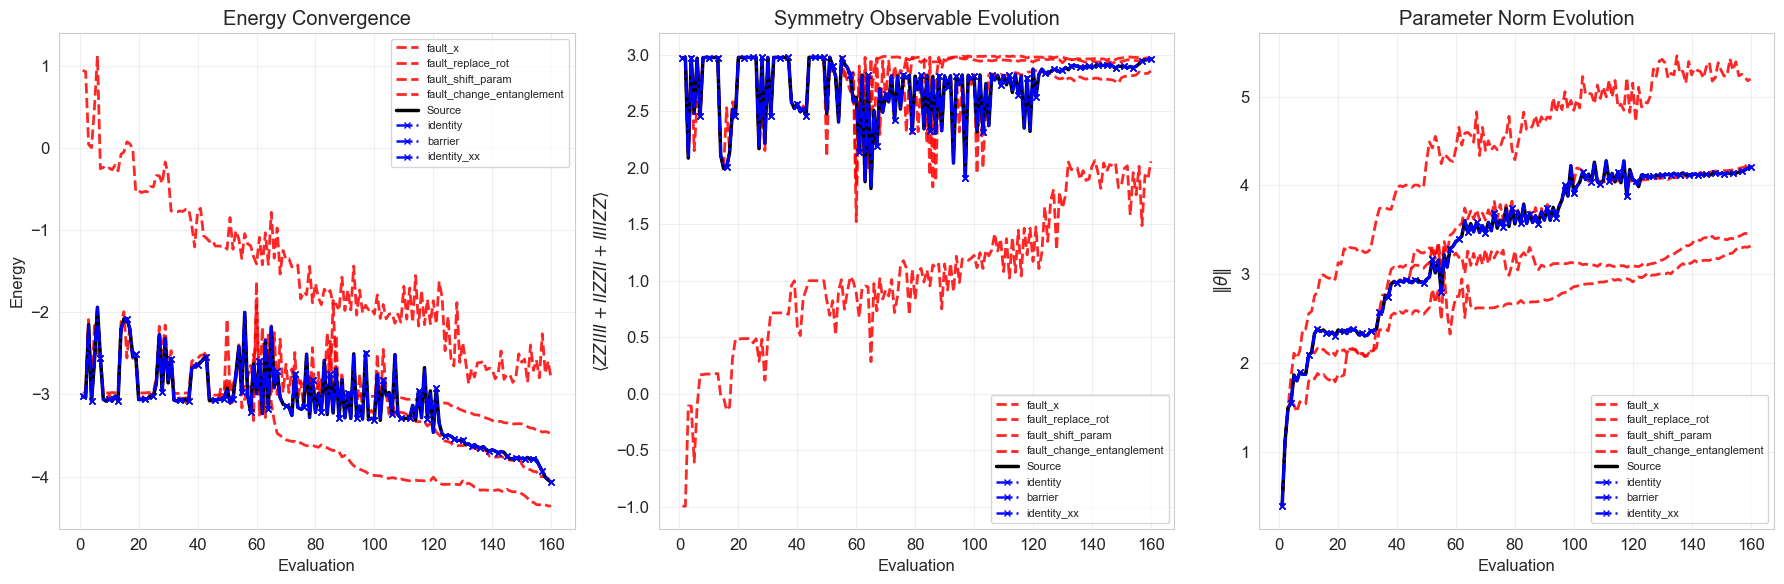

In [18]:
# 6-QUBIT FINAL VQE OPTIMIZATION PATHS

initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
    maxiter=MAXITER,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):

    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
        maxiter=MAXITER,
    )

    followup_traces.append((name, follow_trace))


valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]


# Energy
for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation")
axes[0].set_ylabel("Energy")
axes[0].set_title("Energy Convergence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)


# Symmetry observable
for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation")
axes[1].set_ylabel(r"$\langle ZZIIII + IIZZII + IIIIZZ \rangle$")
axes[1].set_title("Symmetry Observable Evolution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)


# Parameter norm
for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("Parameter Norm Evolution")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_optimization_paths_6q.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_optimization_paths_6q.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [19]:
# THRESHOLD SENSITIVITY TEST for the 6 qubit statevector

energy_thresholds = [1e-3, 1e-2, 1e-1, 0.25, 0.5, 1.0]
symmetry_thresholds = [1e-3, 1e-2, 1e-1, 0.25, 0.5, 1.0]
param_thresholds = [1e-2, 1e-1, 0.5, 1.0, 2.0, 3.0]

threshold_rows = []

for e_th in energy_thresholds:
    for s_th in symmetry_thresholds:
        for p_th in param_thresholds:

            temp = df_vqe_6q_runs.copy()

            # Recompute violation under this threshold setting
            temp["energy_violation"] = temp["delta_E"] > e_th
            temp["symmetry_violation"] = temp["max_sym_diff"] > s_th
            temp["param_violation"] = temp["max_param_diff"] > p_th

            temp["full_violation"] = (
                temp["energy_violation"]
                | temp["symmetry_violation"]
                | temp["param_violation"]
            )

            # Summarize by relation
            grouped = (
                temp.groupby(["relation", "type"])
                .agg(
                    energy_detection_rate=("energy_violation", lambda x: np.mean(x) * 100),
                    symmetry_detection_rate=("symmetry_violation", lambda x: np.mean(x) * 100),
                    param_detection_rate=("param_violation", lambda x: np.mean(x) * 100),
                    full_detection_rate=("full_violation", lambda x: np.mean(x) * 100),
                )
                .reset_index()
            )

            grouped["energy_threshold"] = e_th
            grouped["symmetry_threshold"] = s_th
            grouped["param_threshold"] = p_th

            threshold_rows.append(grouped)

df_threshold_sensitivity = pd.concat(threshold_rows, ignore_index=True)

# Round for readability
rate_cols = [
    "energy_detection_rate",
    "symmetry_detection_rate",
    "param_detection_rate",
    "full_detection_rate",
]

df_threshold_sensitivity[rate_cols] = df_threshold_sensitivity[rate_cols].round(2)

# Save
df_threshold_sensitivity.to_csv(
    results_dir / "vqe_threshold_sensitivity_6q.csv",
    index=False
)

display(df_threshold_sensitivity.head())

,relation,type,energy_detection_rate,symmetry_detection_rate,param_detection_rate,full_detection_rate,energy_threshold,symmetry_threshold,param_threshold
0,barrier,valid,0.00,0.0,0.0,0.0,0.001,0.001,0.01
1,fault_change_entanglement,fault,100.00,100.0,100.0,100.0,0.001,0.001,0.01
2,fault_replace_rot,fault,96.67,100.0,100.0,100.0,0.001,0.001,0.01
3,fault_shift_param,fault,100.00,100.0,100.0,100.0,0.001,0.001,0.01
4,fault_x,fault,100.00,100.0,100.0,100.0,0.001,0.001,0.01


In [20]:
# COMPACT THRESHOLD SUMMARY BY TYPE

df_threshold_type_summary = (
    df_threshold_sensitivity
    .groupby([
        "energy_threshold",
        "symmetry_threshold",
        "param_threshold",
        "type",
    ])
    .agg(
        mean_energy_detection_rate=("energy_detection_rate", "mean"),
        mean_symmetry_detection_rate=("symmetry_detection_rate", "mean"),
        mean_param_detection_rate=("param_detection_rate", "mean"),
        mean_full_detection_rate=("full_detection_rate", "mean"),
    )
    .reset_index()
)

df_threshold_type_summary = df_threshold_type_summary.round(2)

df_threshold_type_summary.to_csv(
    results_dir / "vqe_threshold_sensitivity_type_summary_6q.csv",
    index=False
)

display(df_threshold_type_summary.head())

,energy_threshold,symmetry_threshold,param_threshold,type,mean_energy_detection_rate,mean_symmetry_detection_rate,mean_param_detection_rate,mean_full_detection_rate
0,0.0,0.0,0.01,fault,99.17,100.0,100.0,100.0
1,0.0,0.0,0.01,valid,0.00,0.0,0.0,0.0
2,0.0,0.0,0.10,fault,99.17,100.0,100.0,100.0
3,0.0,0.0,0.10,valid,0.00,0.0,0.0,0.0
4,0.0,0.0,0.50,fault,99.17,100.0,100.0,100.0


In [21]:
# View selected threshold settings only
selected = df_threshold_sensitivity[
    (df_threshold_sensitivity["energy_threshold"].isin([1e-3, 1e-1, 0.5]))
    & (df_threshold_sensitivity["symmetry_threshold"].isin([1e-3, 1e-1, 0.5]))
    & (df_threshold_sensitivity["param_threshold"].isin([1e-2, 0.5, 2.0]))
]

display(selected)

,relation,type,energy_detection_rate,symmetry_detection_rate,param_detection_rate,full_detection_rate,energy_threshold,symmetry_threshold,param_threshold
0,barrier,valid,0.00,0.00,0.00,0.00,0.001,0.001,0.01
1,fault_change_entanglement,fault,100.00,100.00,100.00,100.00,0.001,0.001,0.01
2,fault_replace_rot,fault,96.67,100.00,100.00,100.00,0.001,0.001,0.01
3,fault_shift_param,fault,100.00,100.00,100.00,100.00,0.001,0.001,0.01
4,fault_x,fault,100.00,100.00,100.00,100.00,0.001,0.001,0.01
...,...,...,...,...,...,...,...,...,...
1206,fault_replace_rot,fault,10.00,83.33,80.00,90.00,0.500,0.500,2.00
1207,fault_shift_param,fault,10.00,96.67,86.67,96.67,0.500,0.500,2.00
1208,fault_x,fault,33.33,100.00,100.00,100.00,0.500,0.500,2.00
1209,identity,valid,0.00,0.00,0.00,0.00,0.500,0.500,2.00


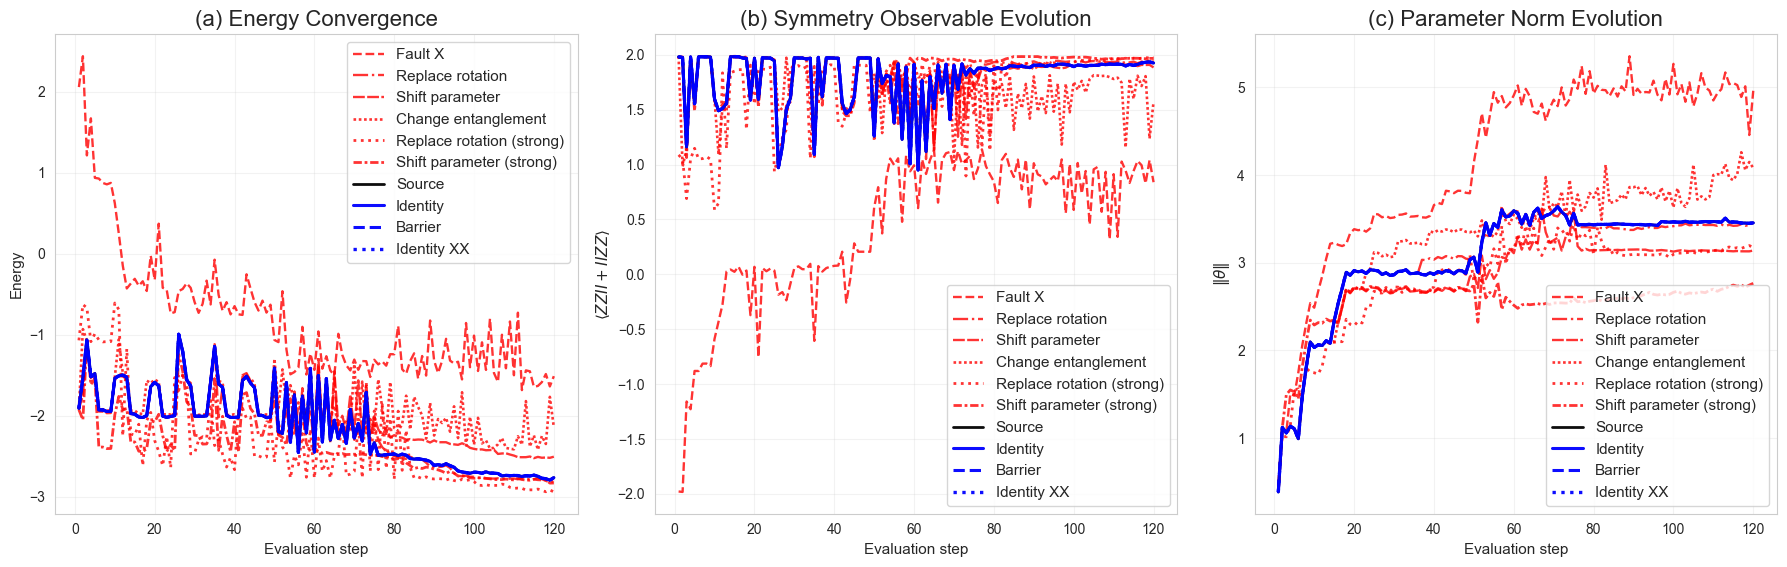

In [13]:
# STATEVECTOR VQE OPTIMIZATION PATHS

def pretty_relation_name(name: str) -> str:
    mapping = {
        "identity": "Identity",
        "barrier": "Barrier",
        "identity_xx": "Identity XX",
        "fault_x": "Fault X",
        "fault_replace_rot": "Replace rotation",
        "fault_replace_rot_strong": "Replace rotation (strong)",
        "fault_shift_param": "Shift parameter",
        "fault_shift_param_strong": "Shift parameter (strong)",
        "fault_change_entanglement": "Change entanglement",
    }
    return mapping.get(name, name)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "lines.linewidth": 2.0,
})

# Use one representative initial point for the figure
initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
    maxiter=MAXITER,
)

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):
    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1_000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
        maxiter=MAXITER,
    )

    followup_traces.append((name, follow_trace))

valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]

valid_style = {
    "identity": {"linestyle": "-",  "linewidth": 2.2},
    "barrier": {"linestyle": "--", "linewidth": 2.2},
    "identity_xx": {"linestyle": ":", "linewidth": 2.4},
}

fault_style = {
    "fault_x": {"linestyle": "--", "linewidth": 1.7},
    "fault_replace_rot": {"linestyle": "-.", "linewidth": 1.7},
    "fault_replace_rot_strong": {"linestyle": ":", "linewidth": 2.0},
    "fault_shift_param": {"linestyle": (0, (5, 1)), "linewidth": 1.7},
    "fault_shift_param_strong": {"linestyle": (0, (3, 1, 1, 1)), "linewidth": 2.0},
    "fault_change_entanglement": {"linestyle": (0, (1, 1)), "linewidth": 1.9},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharex=False)

plot_specs = [
    ("energy", "Energy", "(a) Energy Convergence"),
    ("symmetry", r"$\langle ZZII + IIZZ \rangle$", "(b) Symmetry Observable Evolution"),
    ("param_norm", r"$\|\theta\|$", "(c) Parameter Norm Evolution"),
]

for ax, (ycol, ylabel, title) in zip(axes, plot_specs):
    # Plot faults first
    for name, tr in fault_traces:
        style = fault_style.get(name, {"linestyle": "--", "linewidth": 1.7})
        ax.plot(
            tr["eval"],
            tr[ycol],
            label=pretty_relation_name(name),
            color="red",
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=0.8,
            zorder=1,
        )

    # Plot source next
    ax.plot(
        source_trace["eval"],
        source_trace[ycol],
        label="Source",
        color="black",
        linewidth=2.0,
        alpha=0.95,
        zorder=2,
    )

    # Plot valids last so they stay visible
    for name, tr in valid_traces:
        style = valid_style.get(name, {"linestyle": "-", "linewidth": 2.2})
        ax.plot(
            tr["eval"],
            tr[ycol],
            label=pretty_relation_name(name),
            color="blue",
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=0.95,
            zorder=3,
        )

    ax.set_xlabel("Evaluation step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", frameon=True)

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_optimization_paths.pdf",
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()